In [ ]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from keras.models import Sequential
from keras.layers import Dense

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# Load the dataset
# Assuming you have a CSV file named 'company_strategies.csv' with historical data
data = pd.read_csv('Companies_Stratagies.csv')
print(data)

FileNotFoundError: [Errno 2] No such file or directory: 'Companies_Stratagies.csv'

In [ ]:
print(data.head)
print(data.tail)
print(data.describe)

<bound method NDFrame.head of Empty DataFrame
Columns: [{"cells":[{"cell_type":"code", execution_count:1, metadata:{"executionInfo":{"elapsed":15991, status:"ok", timestamp:1742219068392, user:{"displayName":"THALLAPALLY AKSHITHA, Cse2020 Vel Tech,  Chennai", userId:"03545833239281484146"}, user_tz:-330}, id:"TNdKOYRjNR3j"}, outputs:[], source:["# Step 1: Import necessary libraries\n", import numpy as np\n, import pandas as pd\n, import matplotlib.pyplot as plt\n, from sklearn.model_selection import train_test_split\n, from sklearn.metrics import accuracy_score, classification_report, confusion_matrix\n, from tensorflow import keras\n, from tensorflow.keras.models import Sequential\n, from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten\n, from sklearn.model_selection import train_test_split\n.1, from sklearn.ensemble import RandomForestClassifier\n, import tensorflow as tf\n, import seaborn as sns\n, from sklearn.preprocessing import StandardScaler\n, from sklearn.

In [ ]:
# Create target variable for classification
data['Target'] = (data['Profit'].shift(-1) > data['Profit']).astype(int)

KeyError: 'Profit'

In [ ]:
# Drop rows with NaN values
data.dropna(inplace=True)

In [ ]:
# Gathering the Companies Strategies Information
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[['Profit', 'RATE', 'R&D Spend', 'Marketing Spend']])
print(scaled_data)

[[-2.69275073 -0.26117734  0.40334761  7.06703793]
 [-2.70188375 -0.26117734  0.27164969  6.00009622]
 [-2.71630227 -0.26117734 -0.16667317  4.62403411]
 ...
 [ 0.40414042  2.06482396  0.20386188  0.46982947]
 [ 0.40415986  2.06800155  0.20386188  0.46986773]
 [ 0.40417929  2.07117915  0.20386188  0.46990599]]


In [ ]:
# Create features and target variable
X = scaled_data[:, :-1]
y = data['Target'].values

In [ ]:
print(type(X))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train)

[[ 0.23531554  0.59995156  0.20386188]
 [ 0.22348148 -0.75052733  0.20386188]
 [ 0.39149022 -0.03556792  0.20386188]
 ...
 [ 0.14610341  0.61901714  0.20386188]
 [-2.90961142  0.53957721 -0.11147589]
 [ 0.34829297 -0.75052733  0.20386188]]


In [ ]:
# Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)
print(f'Decision Tree Accuracy: {dt_accuracy}')

Decision Tree Accuracy: 0.983132530120482


In [ ]:
# Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f'Random Forest Accuracy: {rf_accuracy}')

Random Forest Accuracy: 0.9847389558232932


In [ ]:
# Neural Network using TensorFlow
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))
nn_predictions = (model.predict(X_test) > 0.5).astype(int).flatten()
nn_accuracy = accuracy_score(y_test, nn_predictions)
print(f'Neural Network Accuracy: {nn_accuracy}')

Epoch 1/20
467/467 [==============================] - 4s 4ms/step - loss: 0.1275 - accuracy: 0.9777 - val_loss: 0.0373 - val_accuracy: 0.9837
Epoch 2/20
467/467 [==============================] - 1s 2ms/step - loss: 0.0338 - accuracy: 0.9857 - val_loss: 0.0290 - val_accuracy: 0.9863
Epoch 3/20
467/467 [==============================] - 1s 2ms/step - loss: 0.0302 - accuracy: 0.9861 - val_loss: 0.0273 - val_accuracy: 0.9877
Epoch 4/20
467/467 [==============================] - 1s 2ms/step - loss: 0.0294 - accuracy: 0.9857 - val_loss: 0.0283 - val_accuracy: 0.9863
Epoch 5/20
467/467 [==============================] - 1s 2ms/step - loss: 0.0291 - accuracy: 0.9864 - val_loss: 0.0267 - val_accuracy: 0.9882
Epoch 6/20
467/467 [==============================] - 1s 2ms/step - loss: 0.0288 - accuracy: 0.9864 - val_loss: 0.0268 - val_accuracy: 0.9874
Epoch 7/20
467/467 [==============================] - 3s 6ms/step - loss: 0.0290 - accuracy: 0.9861 - val_loss: 0.0268 - val_accuracy: 0.9877
Epoch 

In [ ]:
# Deep Learning with Keras
model = Sequential()
model.add(Dense(units=64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)
dl_predictions = (model.predict(X_test) > 0.5).astype(int).flatten()
dl_accuracy = accuracy_score(y_test, dl_predictions)
print(f'DL Accuracy: {dl_accuracy}')

Epoch 1/10
467/467 [==============================] - 2s 2ms/step - loss: 0.0891 - accuracy: 0.9815
Epoch 2/10
467/467 [==============================] - 1s 2ms/step - loss: 0.0308 - accuracy: 0.9866
Epoch 3/10
467/467 [==============================] - 1s 2ms/step - loss: 0.0303 - accuracy: 0.9862
Epoch 4/10
467/467 [==============================] - 1s 3ms/step - loss: 0.0300 - accuracy: 0.9859
Epoch 5/10
467/467 [==============================] - 1s 3ms/step - loss: 0.0294 - accuracy: 0.9861
Epoch 6/10
467/467 [==============================] - 1s 2ms/step - loss: 0.0293 - accuracy: 0.9861
Epoch 7/10
467/467 [==============================] - 1s 2ms/step - loss: 0.0293 - accuracy: 0.9864
Epoch 8/10
467/467 [==============================] - 1s 2ms/step - loss: 0.0292 - accuracy: 0.9865
Epoch 9/10
467/467 [==============================] - 1s 3ms/step - loss: 0.0294 - accuracy: 0.9863
Epoch 10/10
117/117 [==============================] - 0s 2ms/step
DL Accuracy: 0.9866131191432396


In [ ]:
# Evaluation
print("Random Forest Classifier Accuracy:", accuracy_score(y_test, rf_predictions))
print("Deep Learning Accuracy:", accuracy_score(y_test, dl_predictions))
print(f'Decision Tree Accuracy: {dt_accuracy}')
print("DL Accuracy:", accuracy_score(y_test, dl_predictions))

Random Forest Classifier Accuracy: 0.9847389558232932
Deep Learning Accuracy: 0.9866131191432396
Decision Tree Accuracy: 0.983132530120482
DL Accuracy: 0.9866131191432396


In [ ]:
# Confusion Matrix :
print("\nConfusion Matrix for #RandomForestClassifier:")
print(confusion_matrix(y_test, rf_predictions))


Confusion Matrix for #RandomForestClassifier:
[[  76   29]
 [  28 3602]]


In [ ]:
# Splitting the dataset into the Training set and Test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=54)
# Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
print(X_test)

[[ 0.11782831  0.33577227  0.20267194]
 [ 0.14506053 -0.85258466  0.20267194]
 [ 0.24437228  0.93153521  0.20267194]
 ...
 [ 0.08066687  1.07413804  0.20267194]
 [ 0.11375128  0.85231141  0.20267194]
 [ 0.38457138  1.71109736  0.20267194]]


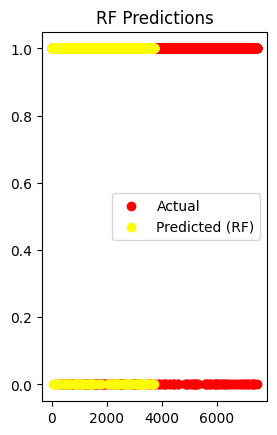

In [ ]:
# Plotting RF predictions
plt.subplot(1, 2, 2)
plt.scatter(range(len(y_test)), y_test, label='Actual', color='red')
plt.scatter(range(len(rf_predictions)), rf_predictions, label='Predicted (RF)', color='yellow')
plt.title('RF Predictions')
plt.legend()
plt.show()

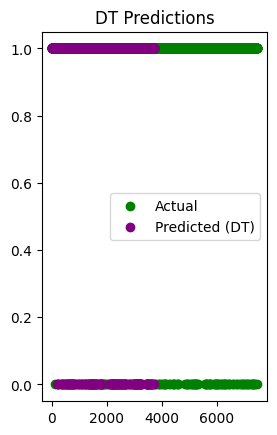

In [ ]:
# Plotting DT predictions
plt.subplot(1, 2, 2)
plt.scatter(range(len(y_test)), y_test, label='Actual', color='green')
plt.scatter(range(len(dt_predictions)), dt_predictions, label='Predicted (DT)', color='purple')
plt.title('DT Predictions')
plt.legend()
plt.show()